# Multilayer Perceptron (MLP)

## Setup

In [5]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_squared_error , r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [10]:
# Load arrays from the compressed archive
data = np.load('datasets/processed_splits.npz')

X_tr_scaled = data['X_tr']
y_tr_scaled = data['y_tr_scaled']
y_tr = data['y_tr']
X_val_scaled = data['X_val']
y_val_scaled = data['y_val_scaled']
y_val = data['y_val']

# import exact scaler instance from the preprocessing notebook
target_scaler = joblib.load('datasets/target_scaler.joblib')
print('All data successfully imported.')


All data successfully imported.


## Training

Initialize a deep model in attempts to learn hierarchial behaviors

In [11]:
# initialize sequential multilayer perceptron
mlp_model = models.Sequential([
    # no. of input neurons matches number of features
    layers.Input(shape=(100,)),

    # dense layers 
    layers.Dense(64, activation='relu'),
    # introduce dropout in the first dense layer as a form of regularization
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),

    # 2 output neurons map to feature to be extracted [kappa, beta]
    layers.Dense(2, activation='linear')
])

mlp_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# callbacks to implement regularization
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# configure MLP hyperparameters and fit to training set
history = mlp_model.fit(
    X_tr_scaled, y_tr_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    # verbose=1
)


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4332 - mae: 0.5063 - val_loss: 0.2473 - val_mae: 0.3726
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1524 - mae: 0.2953 - val_loss: 0.0823 - val_mae: 0.2192
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0795 - mae: 0.2154 - val_loss: 0.0613 - val_mae: 0.1905
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0630 - mae: 0.1903 - val_loss: 0.0495 - val_mae: 0.1659
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0558 - mae: 0.1782 - val_loss: 0.0431 - val_mae: 0.1539
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0495 - mae: 0.1684 - val_loss: 0.0437 - val_mae: 0.1550
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0470 - mae: 0.1623 - val_loss: 0.0391 - val_mae: 0.1451
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0430 - mae: 0.1560 - val_loss: 0.0403 - val_mae: 0.1510
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.040

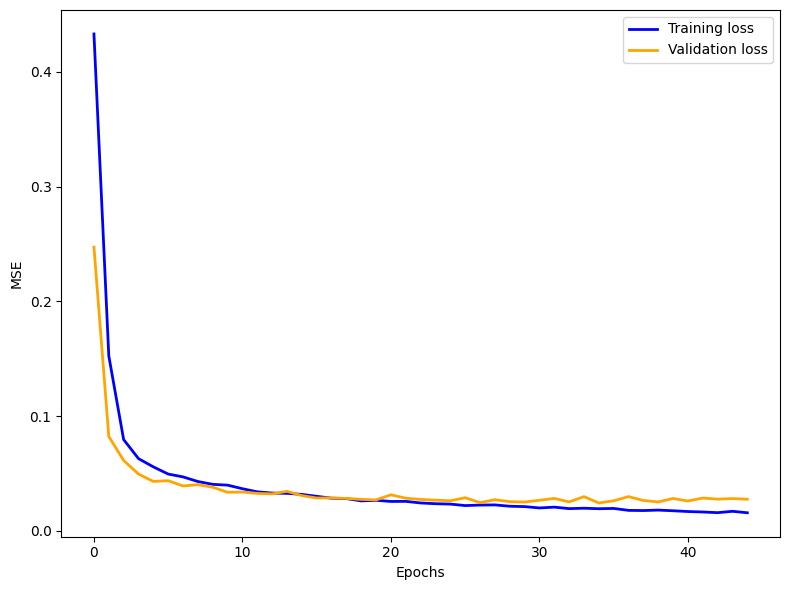

In [12]:
# plot training curve of loss vs epochs
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], linewidth=2, label='Training loss', color='blue')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation loss', color='orange')

plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# make predictions on training and validation sets and undo feature scaling
y_pred_mlp_scaled_tr = mlp_model.predict(X_tr_scaled)
y_pred_mlp_scaled = mlp_model.predict(X_val_scaled)
y_pred_mlp_tr = target_scaler.inverse_transform(y_pred_mlp_scaled_tr)
y_pred_mlp = target_scaler.inverse_transform(y_pred_mlp_scaled)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step


## Final Model

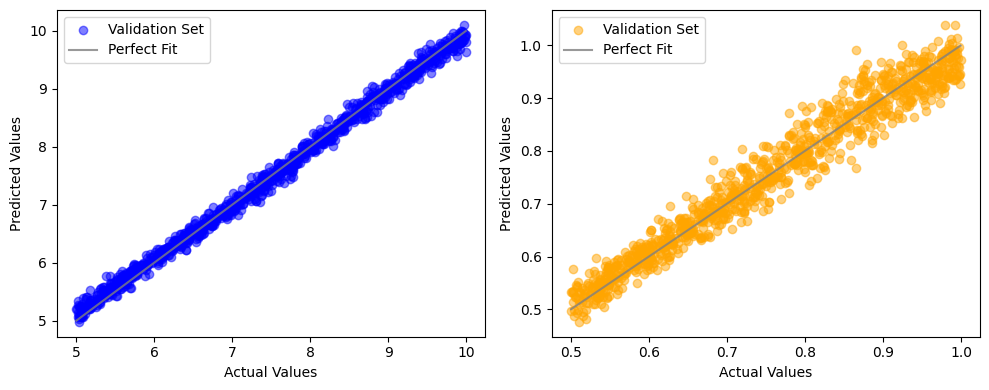

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# plot kappa predictions using optimal MLP model
ax1.scatter(y_val[:,0], y_pred_mlp[:,0], color='blue', alpha=0.5, label='Validation Set')
# line of perfect fit (y=x)
ideal_line_kappa = np.linspace(min(y_val[:,0]), max(y_val[:,0]), 100)
ax1.plot(ideal_line_kappa, ideal_line_kappa, color='grey', alpha=0.8, label='Perfect Fit')

ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.legend()

# plot beta predictions using optimal MLP model
ax2.scatter(y_val[:,1], y_pred_mlp[:,1], color='orange', alpha=0.5, label='Validation Set')
# line of perfect fit (y=x)
ideal_line_beta = np.linspace(min(y_val[:,1]), max(y_val[:,1]), 100)
ax2.plot(ideal_line_beta, ideal_line_beta, color='grey', alpha=0.8, label='Perfect Fit')

ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
# MLP quantification metrics

# validation set
mlp_kappa_rmse_val = root_mean_squared_error(y_val[:,0], y_pred_mlp[:,0])
mlp_kappa_mse_val = mean_squared_error(y_val[:,0], y_pred_mlp[:,0])
mlp_kappa_r2_val = r2_score(y_val[:,0], y_pred_mlp[:,0])

mlp_beta_rmse_val = root_mean_squared_error(y_val[:,1], y_pred_mlp[:,1])
mlp_beta_mse_val = mean_squared_error(y_val[:,1], y_pred_mlp[:,1])
mlp_beta_r2_val = r2_score(y_val[:,1], y_pred_mlp[:,1])

# training set
mlp_kappa_rmse_tr = root_mean_squared_error(y_tr[:,0], y_pred_mlp_tr[:,0])
mlp_kappa_mse_tr = mean_squared_error(y_tr[:,0], y_pred_mlp_tr[:,0])
mlp_kappa_r2_tr = r2_score(y_tr[:,0], y_pred_mlp_tr[:,0])

mlp_beta_rmse_tr = root_mean_squared_error(y_tr[:,1], y_pred_mlp_tr[:,1])
mlp_beta_mse_tr = mean_squared_error(y_tr[:,1], y_pred_mlp_tr[:,1])
mlp_beta_r2_tr = r2_score(y_tr[:,1], y_pred_mlp_tr[:,1])

print('\nKappa | Training | Validation')
print('------------------------------')
print(f'RMSE | {mlp_kappa_rmse_tr:.3f} | {mlp_kappa_rmse_val:.3f}')
print(f'MSE | {mlp_kappa_mse_tr:.3f} | {mlp_kappa_mse_val:.3f}')
print(f'R^2 | {mlp_kappa_r2_tr:.3f} | {mlp_kappa_r2_val:.3f}')

print('\nBeta | Training | Validation')
print('------------------------------')
print(f'RMSE | {mlp_beta_rmse_tr:.3f} | {mlp_beta_rmse_val:.3f}')
print(f'MSE | {mlp_beta_mse_tr:.3f} | {mlp_beta_mse_val:.3f}')
print(f'R^2 | {mlp_beta_r2_tr:.3f} | {mlp_beta_r2_val:.3f}')



Kappa | Training | Validation
------------------------------
RMSE | 0.100 | 0.110
MSE | 0.010 | 0.012
R^2 | 0.995 | 0.994

Beta | Training | Validation
------------------------------
RMSE | 0.019 | 0.030
MSE | 0.000 | 0.001
R^2 | 0.983 | 0.958


Save optimimal MLP model for comparison with other models 

In [16]:
mlp_model.save('models/mlp_model.keras')
print('Optimized MLP model saved')


Optimized MLP model saved
